### Librerias e importaciones

In [1]:
import sys
sys.path.append("../src")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import lightgbm
import catboost


from preprocessing import preprocesamiento_pre_split, preprocesamiento_post_split, onehot_encoding
from data_splitting import train_val_split
from plots import eda_visualizacion_suvs

In [2]:
#IGNORAR ESTA CELDA
%load_ext autoreload
%autoreload 2

### EDA

**Preprocessing**

In [3]:
data = pd.read_csv('../data/pf_suvs.csv')

In [4]:
print("\n Dataset ALEATORIO")
print(data.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n DATA INFO")
print(data.info())



 Dataset ALEATORIO
      Unnamed: 0    Marca    Modelo     Año           Versión   Color  \
971          971  Hyundai    Tucson  2024.0      1.6 Tgdi Tct    Azul   
4941        4941     Jeep  Cherokee  1998.0         4.0 Sport   Verde   
2901        2901     Jeep  Cherokee  2005.0       3.7 Limited    Gris   
7778        7778      Kia  Sportage  2024.0  1.6 Ex T-Gdi 4X2    Gris   
7784        7784    Honda      HR-V  2016.0    1.8 Lx 2wd Cvt  Blanco   

     Tipo de combustible  Puertas Transmisión Motor Tipo de carrocería  \
971                Nafta      5.0  Automática   1.6                SUV   
4941               Nafta      5.0      Manual   4.0                SUV   
2901               Nafta      5.0      Manual   3.7                SUV   
7778               Nafta      5.0  Automática   1.6                SUV   
7784               Nafta      5.0  Automática   1.8                SUV   

     Con cámara de retroceso Kilómetros                         Título  \
971                   

In [5]:
summary = pd.DataFrame({
    "dtype": data.dtypes,
    "nulos": data.isnull().sum(),
    "unicos": data.nunique()
})
summary

,dtype,nulos,unicos
Unnamed: 0,int64,0,18254
Marca,str,0,47
Modelo,str,0,137
Año,float64,0,40
Versión,str,0,2072
Color,str,389,70
Tipo de combustible,str,0,8
Puertas,float64,0,7
Transmisión,str,15,4
Motor,str,38,271


In [6]:
print("\n DATA DESCRIPCION " )
data.describe()


 DATA DESCRIPCION 


,Unnamed: 0,Año,Puertas,Precio
count,18254.000000,18254.000000,18254.000000,1.825400e+04
mean,9126.500000,2042.796209,18.167306,1.760162e+07
std,5269.620242,3217.260996,891.766121,1.720810e+07
min,0.000000,1981.000000,2.000000,1.110000e+02
25%,4563.250000,2016.000000,5.000000,3.190000e+04
50%,9126.500000,2019.000000,5.000000,1.720000e+07
75%,13689.750000,2024.000000,5.000000,2.995000e+07
max,18253.000000,436694.000000,60252.000000,3.495000e+08


*El análisis exploratorio permitió detectar la existencia de valores faltantes en diversas variables descriptivas del vehículo, entre ellas Color, Transmisión, Motor y Con cámara de retroceso. Debido a que estas variables pueden influir significativamente en el valor de mercado de una SUV, se optó por imputar los datos faltantes en lugar de descartar las observaciones correspondientes, preservando así el tamaño de la muestra disponible para entrenamiento.*

*Por otra parte, se observó que gran parte de los atributos del dataset se encuentran representados mediante variables categóricas de tipo texto. Dado que los algoritmos de aprendizaje supervisado utilizados trabajan sobre representaciones numéricas, será necesario transformar dichas variables mediante One-Hot Encoding, generando una codificación binaria que permita incorporar esta información al modelo sin introducir relaciones artificiales entre categorías*

***PREPROCESAMIENTO: Limpieza de datos necesaria para no afectar el entrenamiento del modelo.***

**Justificacion de desiciones tomadas**


1. ` La variable Unnamed`: 0 actúa únicamente como identificador de cada publicación y no aporta información relevante para la predicción del precio, por lo que fue eliminada.
2. `Cambio de moneda a USD`Para garantizar la comparabilidad entre observaciones y evitar que la moneda introduzca sesgos en los modelos, todos los precios fueron convertidos a dólares utilizando un único tipo de cambio de referencia y se eliminio la columna ya que no aportaba informacion.
3. Se eliminó columnas(features) como `Unnamed`, `Tipo de carroceria`, `Titulo`, `Version`

4. `Imputacion de Puertas`: se observaron valores inconsistentes en la variable Puertas. Dado que el conjunto de datos contiene exclusivamente SUVs, se decidió homogeneizar los valores restantes utilizando cinco puertas como valor por defecto

In [7]:
display(data["Puertas"].value_counts().sort_index())

Puertas
2.0           10
3.0          105
4.0          399
5.0        17731
6.0            3
7.0            2
60252.0        4
Name: count, dtype: int64

5. `Motor`: presentaba únicamente 38 valores faltantes (menos del 0.3% del dataset). Debido a su baja proporción, se optó por eliminar dichas observaciones en lugar de imputarlas para evitar introducir ruido artificial. A su vez , los datos estaban en str se cambiaron a valor numerico.


    La variable Motor se encontraba almacenada como texto y presentaba múltiples formatos de escritura, por ejemplo "2.0 TSI", "1.6 THP", "2.8 TD" o "1.3 Turbo". Con el objetivo de obtener una variable numérica consistente, se extrajo la cilindrada del motor y se transformó a formato float.

In [8]:
nulos_motor = data["Motor"].isna().sum()
total = len(data)

print(f"Nulos en Motor: {nulos_motor}")
print(f"Total de registros: {total}")
print(f"Porcentaje de nulos: {100*nulos_motor/total:.3f}%")

Nulos en Motor: 38
Total de registros: 18254
Porcentaje de nulos: 0.208%


In [9]:
print(data["Motor"].unique().tolist())

['1.5', '2.0 L 230 CV  350 TSI', '1.4', '2.4', '1.5 TURBO', '2.0', '3.6', '1.8', '1.0', '1.3', '1.2 TURBO', '1.2', '1.6', 'Nafta 2.0 (148cv) + Electrico (184.5cv)', '3.0', '2.2', '2.5', '1', '2.5l Hibrida', '2.8', '2.7', 'TURBOALIMENTADO', 'TURBO DIESEL INYECCION', '4.8', '2.9', '1.3T', 'INYECCION MULTI PUNTO', nan, 'diesel', '4.4', '3.0 440HP', '2.0 hurrican 4 272 cv 400nm', '6.4', '5.2', '1.5t', '1.4 TFSI', '2.3', '4.7', '2.0 TDI 140CV', '3.7', '3.2', '1500', '3.8', '1.3 TURBO', '4.5', '3', '2', '2.0 TURBO', '4.0 Nafta', '1.8L', '192 HP', '1.6 Naftero', '5.0', '1.5 TURBO 185 HP', 'P8 (408hp)', '1,3 t 175 cv 270 Nm', '1.6 Turbo', '4.2', '4.0', '1.0 tsi', '1.5 16V', '1.0 200 TSI', '1.8 de 140 hp', '2.0 350TSI', '3.5', '1.3L', '1.3 Turbo', '1.0 TURBO', '1.3 TURBO NAFTA 175CV AT9', 'Motor naftero 1.8 105 CV 161 Nm', '1.0 3 CILINDROS', 'v8 302', '3.3 V6 TD 304cv 700 NM de torque', '1.5 turbo', 'TURBO 2 LITROS', '1.6 MSI Nafta', '1.0T', '6.1', '2500', '2.4L', 'V6 PLUG IN HYBRID 460HP', '2.

In [10]:
motor_extraido = (
    data["Motor"]
    .str.extract(r'(\d+[.,]\d+)')[0]
)

perdidos = data[
    data["Motor"].notna() &
    motor_extraido.isna()
]

print(len(perdidos))
display(perdidos["Motor"].value_counts().head(50))

429


Motor
INYECCION MULTI PUNTO                         157
TURBOALIMENTADO                                82
1                                              67
2                                              41
TURBO DIESEL INYECCION                         10
Turbo 140 CV                                    4
1600                                            3
1500                                            2
192 HP                                          2
V6 PLUG IN HYBRID 460HP                         2
v8                                              2
300 HP                                          2
Turbo con 205 cv                                2
NAFTA                                           2
T8 462hp Plug In Hybrid                         2
Chevrolet                                       2
16000                                           2
Eléctrico                                       2
2000                                            2
Turbo 156 CV                                

Durante este proceso se detectaron 429 registros (2.35% del conjunto de datos) cuyo contenido no permitía identificar una cilindrada válida, incluyendo descripciones genéricas como "Turboalimentado", "Inyección multipunto" o valores evidentemente erróneos. Debido a su baja proporción respecto del total de observaciones, dichos registros fueron eliminados del análisis.

6. `Kilometros`: Se transformó a valor numérico para garantizar un tratamiento consistente. Además se crea feature ¨0 Km¨ que indica vehiculo nuevo o usado.

7. `Descripcion` : contiene texto libre que no puede ser utilizado directamente por modelos de regresion tradicionales. Se construyó un score basado en palabras clave positivas y negativas asociadas al estado general del vehículo, documentación, mantenimiento y equipamiento. El resultado se transformó en una escala numérica entre 1 y 10.

8. `Marcas`:Se unifican las muestras de Marcas para evitar duplucados , y/o reconocimiento erroneo de una Marca. 

In [11]:
print(data["Marca"].unique().tolist())

['Ford', 'Volkswagen', 'Jeep', 'BAIC', 'Kia', 'Hyundai', 'Porsche', 'Peugeot', 'Fiat', 'Chevrolet', 'Citroën', 'BMW', 'Audi', 'Honda', 'Nissan', 'Mercedes-Benz', 'Renault', 'Suzuki', 'Toyota', 'D.S.', 'Chery', 'Daihatsu', 'SsangYong', 'Dodge', 'JAC', 'Land Rover', 'Alfa Romeo', 'Haval', 'Volvo', 'Lifan', 'Mini', 'D·S', 'Mitsubishi', 'Range Rover', 'Hiunday', 'Jetour', 'GWM', 'KAIYI', 'Lexus', 'Isuzu', 'Rrenault', 'Subaru', 'Jetur', 'DS AUTOMOBILES', 'hiunday', 'Jaguar', 'Vol']


In [12]:
data_pre = preprocesamiento_pre_split(data)
print('Tamaño final del dataset -> ', data_pre.shape)

Tamaño final del dataset ->  (18206, 14)


**NUEVO DATASET**

In [13]:
print("\n Dataset NUEVO, ALEATORIO")
print(data_pre.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n data_pre INFO")
print(data_pre.info())
print("\n data_pre DESCRIPCION " )
print(data_pre.describe())


 Dataset NUEVO, ALEATORIO
           Marca          Modelo     Año     Color Tipo de combustible  \
17402       Ford        Ecosport  2022.0    Blanco               Nafta   
1074   Chevrolet         Tracker  2019.0      Rojo               Nafta   
8541        Jeep  Grand Cherokee  2008.0      Gris               Nafta   
13881     Toyota    Land Cruiser  2013.0  Plateado              Diésel   
8965        Jeep        Renegade  2022.0      Gris               Nafta   

       Puertas Transmisión Motor Con cámara de retroceso  Kilómetros  \
17402      5.0      Manual   1.5                     NaN     12000.0   
1074       5.0      Manual   1.8                      Sí     73000.0   
8541       5.0  Automática   4.7                      No    365000.0   
13881      5.0  Automática   4.5                     NaN    142000.0   
8965       5.0  Automática   1.8                     NaN     92000.0   

             Precio Tipo de vendedor  0km  Score Descripción  
17402  31652.724395    concesion

In [14]:
summary = pd.DataFrame({
    "dtype": data_pre.dtypes,
    "nulos": data_pre.isnull().sum(),
    "unicos": data_pre.nunique()
})
summary

,dtype,nulos,unicos
Marca,str,0,41
Modelo,str,0,136
Año,float64,0,39
Color,str,389,69
Tipo de combustible,str,0,8
Puertas,float64,0,2
Transmisión,str,11,4
Motor,str,0,268
Con cámara de retroceso,str,13542,2
Kilómetros,float64,431,2120


**VISUALIZACION DEL EDA HASTA AHORA**

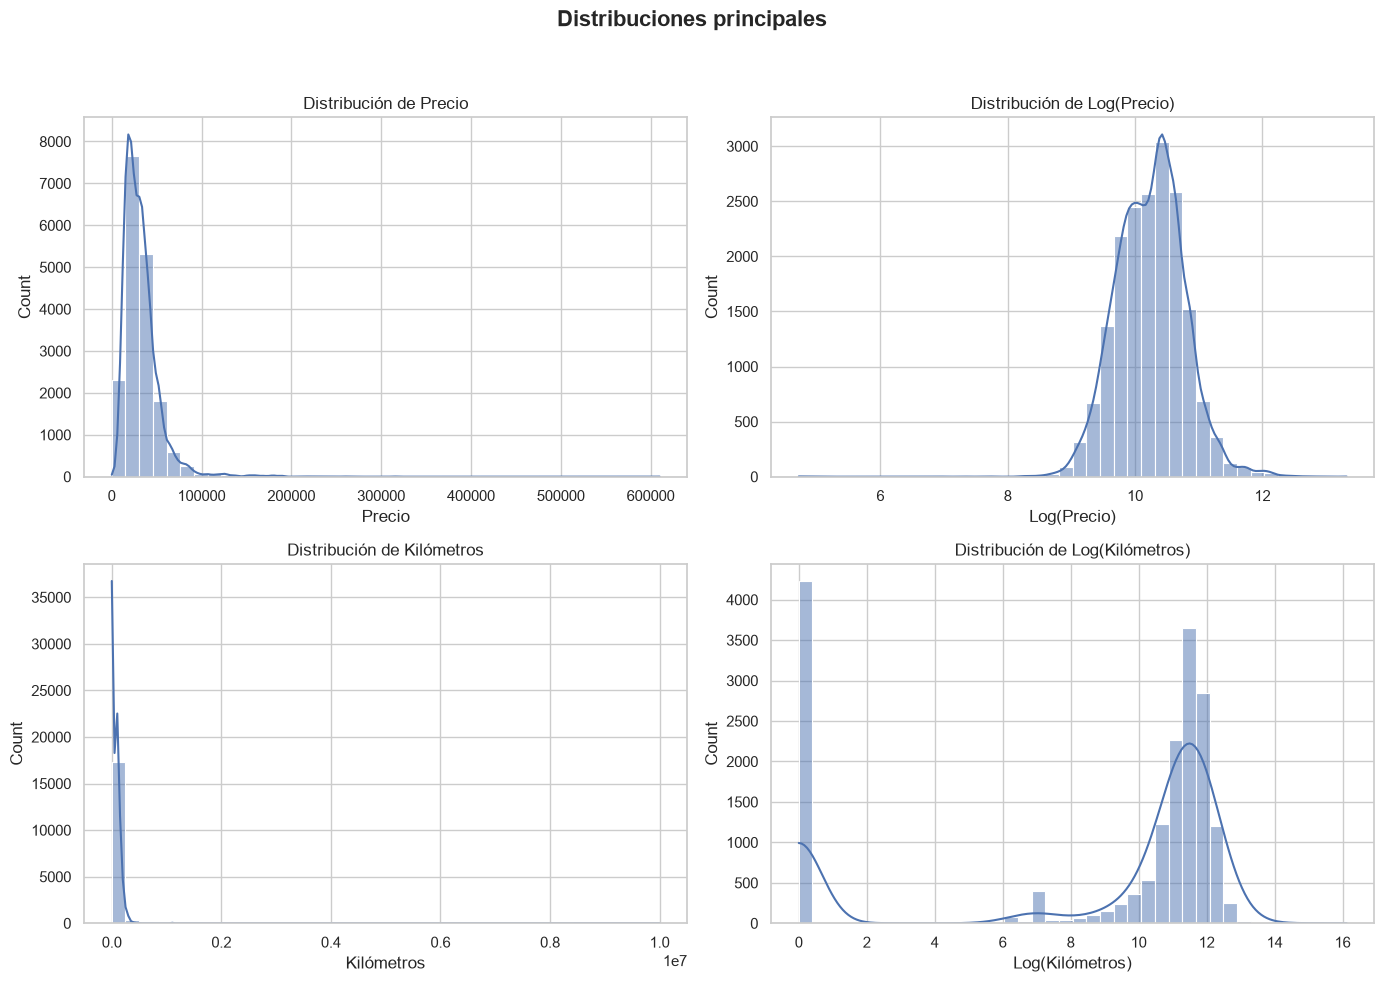

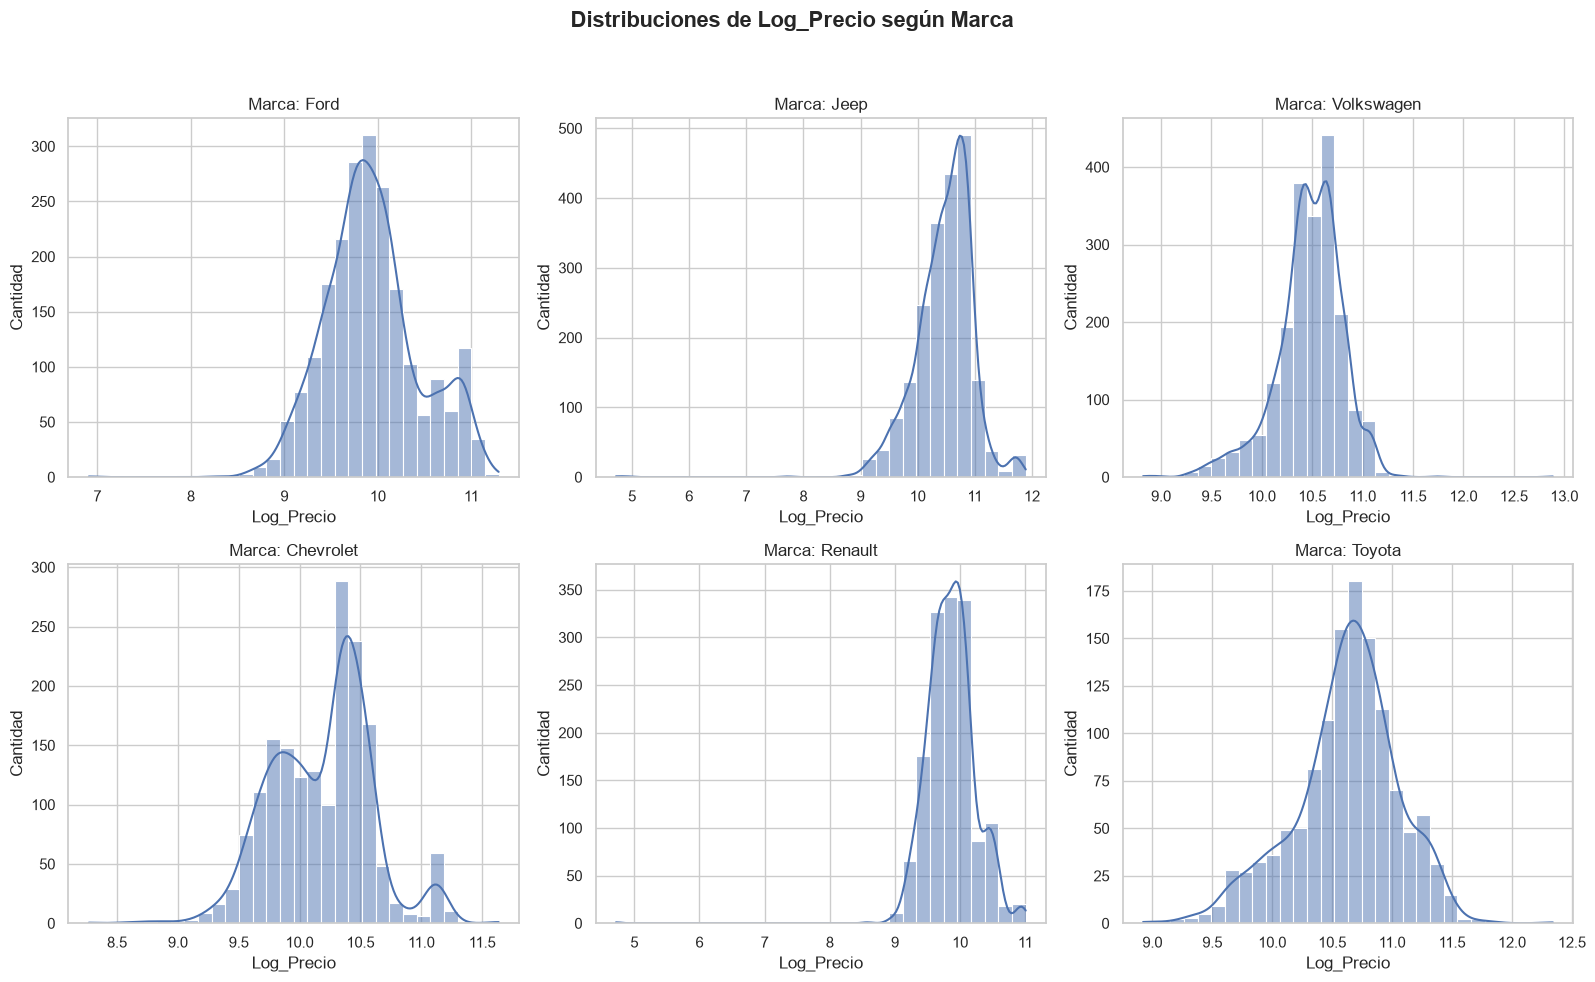

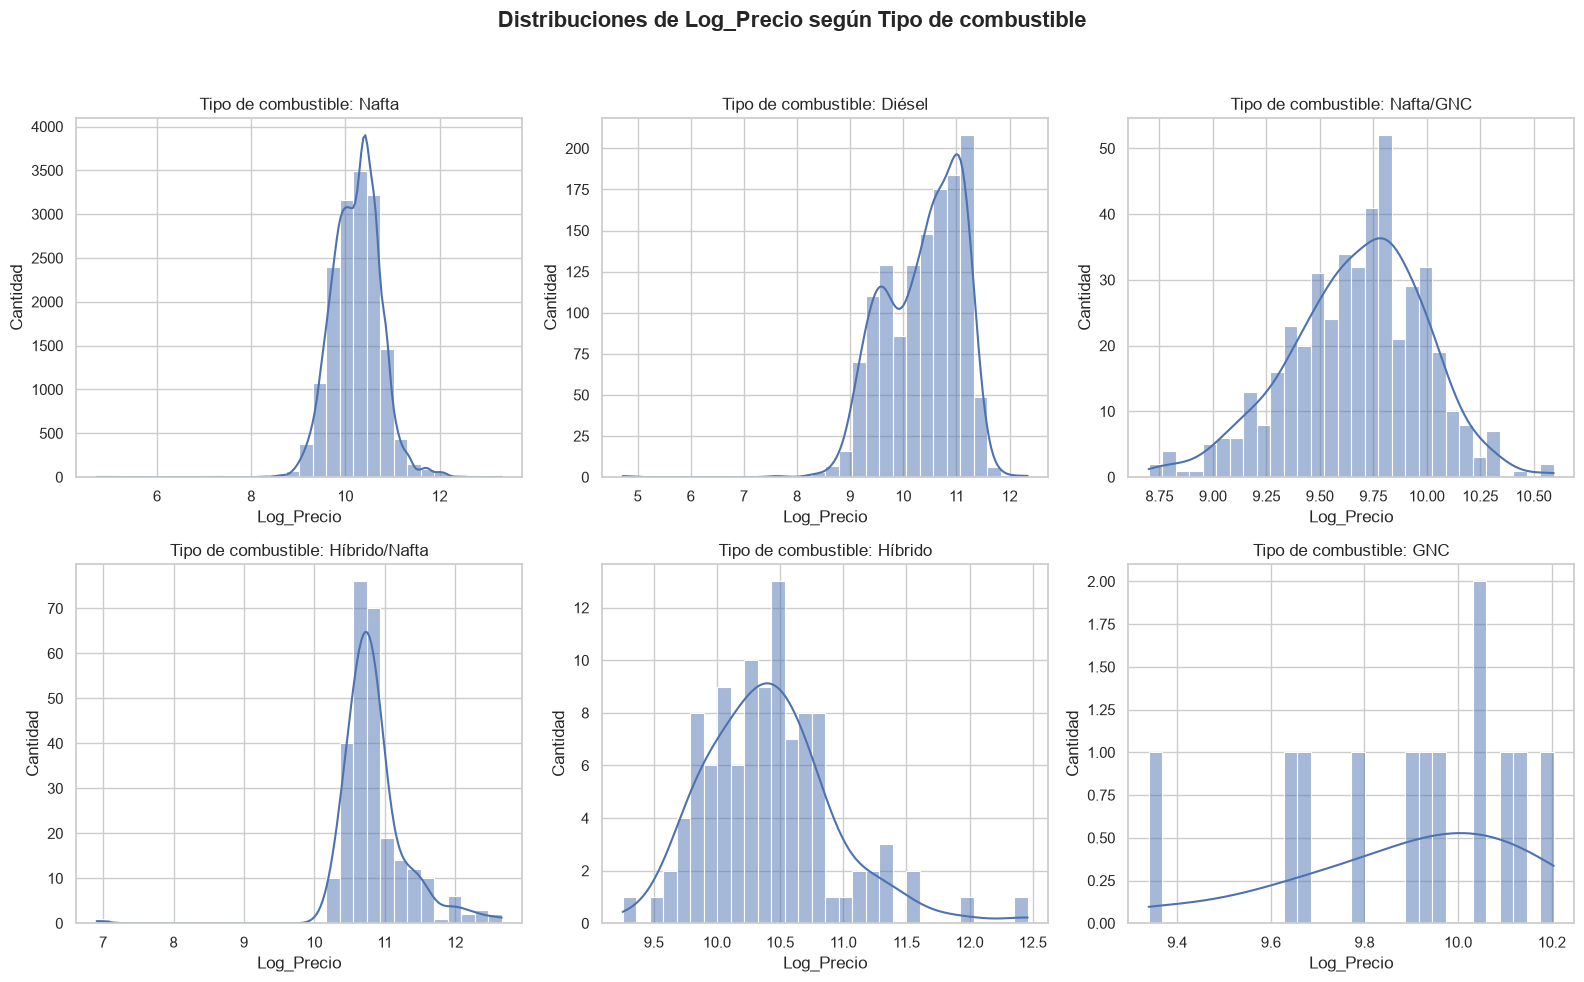

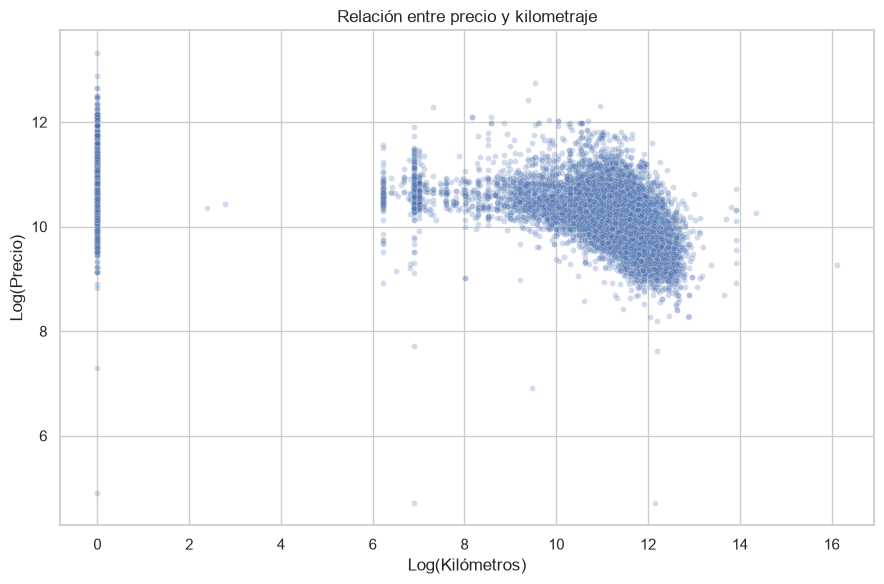

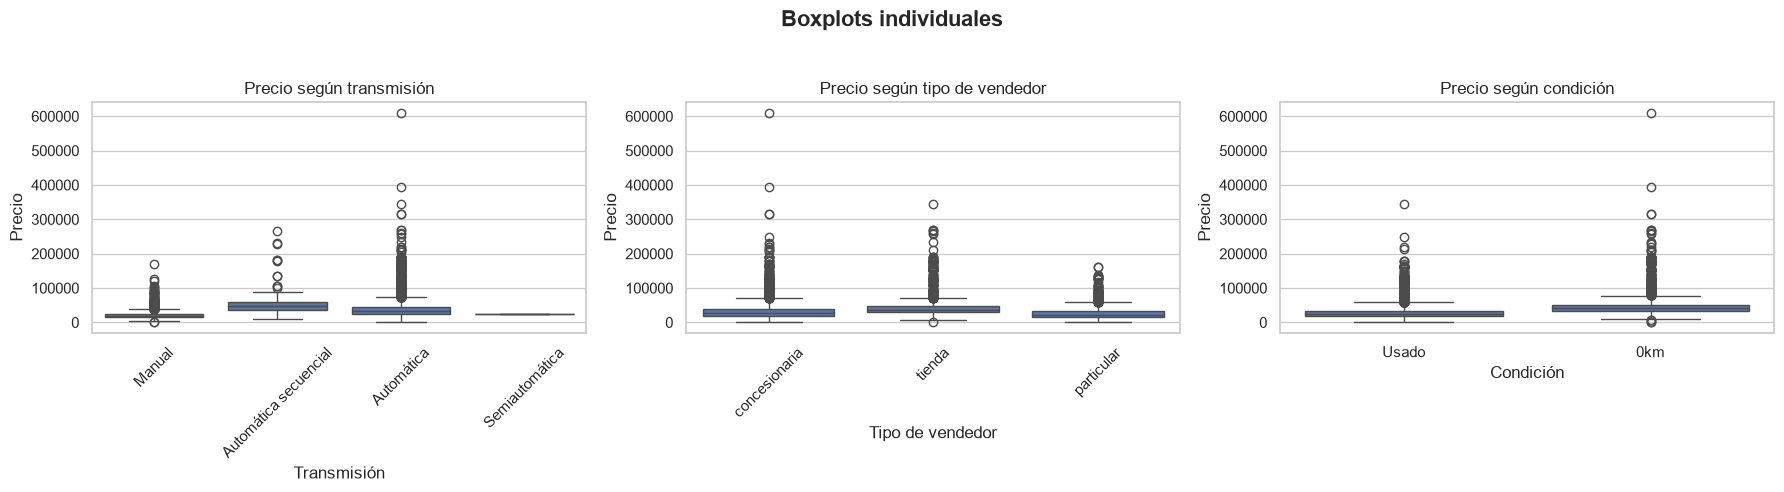

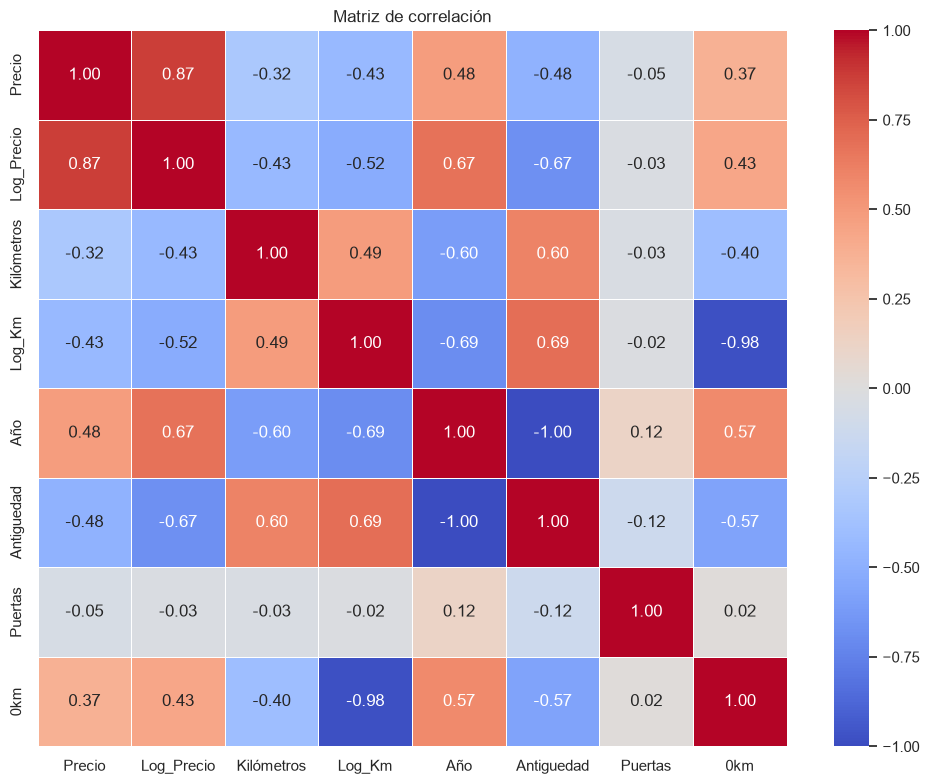

In [15]:
#Plots
eda_visualizacion_suvs(data_pre)

Para terminar con el ***preprocesamiento de datos***, se aplica el split para poder obtener la moda calculada sobre el conjunto de train, y asi poder completar los valores faltantes de las features "color", "transmision", "camara"  evitando el data leakage.

In [16]:
train, val = train_val_split(data_pre)

Tamaño conjunto de entrenamiento -> (14564, 14), 
Tamaño conjunto de validación -> (3642, 14)


In [17]:
#Preprocessing post split using the train parameters
train, val = preprocesamiento_post_split(train, val)

In [18]:
#One-Hot Encoding sobre las columnas con baja cardinalidad
columnas_oh = ['Tipo de combustible', 'Tipo de vendedor', 'Transmisión', 'Con cámara de retroceso']
train, val = onehot_encoding(train, val, columnas_oh)

In [19]:
print('Final del preprocesamiento sobre Entrenamiento')
summary = pd.DataFrame({
    "dtype": train.dtypes,
    "nulos": train.isnull().sum(),
    "unicos": train.nunique()
})
summary

Final del preprocesamiento sobre Entrenamiento


,dtype,nulos,unicos
Marca,str,0,41
Modelo,str,0,136
Año,float64,0,39
Color,str,0,63
Puertas,float64,0,2
Motor,str,0,235
Kilómetros,float64,0,1830
Precio,float64,0,2577
0km,int64,0,2
Score Descripción,int64,0,10


In [20]:
print('Final del preprocesamiento sobre Validación')
summary = pd.DataFrame({
    "dtype": val.dtypes,
    "nulos": val.isnull().sum(),
    "unicos": val.nunique()
})
summary

Final del preprocesamiento sobre Validación


,dtype,nulos,unicos
Marca,str,0,35
Modelo,str,0,114
Año,float64,0,33
Color,str,0,32
Puertas,float64,0,2
Motor,str,0,104
Kilómetros,float64,0,773
Precio,float64,0,1204
0km,int64,0,2
Score Descripción,int64,0,8


### MODELOS

### Comparison bewtween models

### Final Model